<a href="https://colab.research.google.com/github/Francheskacisterna/Evaluaci-n_n1/blob/main/EvaluacionDP_n1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes con una red neuronal MLP

En este trabajo se implementa una red neuronal multicapa (MLP) para clasificar imágenes del dataset Fashion-MNIST.

El objetivo es cargar y preprocesar los datos, entrenar el modelo, evaluar su desempeño mediante métricas de clasificación y comparar distintas configuraciones para identificar la alternativa con mejor rendimiento.

In [ ]:
import numpy as np
import gzip
import matplotlib.pyplot as plt

## Definición de funciones para cargar el dataset

El dataset Fashion-MNIST fue entregado en archivos comprimidos `.gz`, por lo que fue necesario definir funciones para leer las imágenes y las etiquetas.

Las imágenes se cargan como matrices de 28x28 píxeles en escala de grises, mientras que las etiquetas representan la clase de cada prenda.

**Nota:** Para leer correctamente los archivos se utilizó `np.frombuffer`, omitiendo los metadatos iniciales con `offset` (16 bytes en imágenes y 8 bytes en etiquetas).

In [ ]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        images = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return labels

### Carga de datos de entrenamiento y prueba

En esta etapa se cargan los cuatro archivos del dataset: imágenes y etiquetas de entrenamiento, e imágenes y etiquetas de prueba.

Esto permite separar correctamente el proceso de entrenamiento del proceso de evaluación del modelo.

In [ ]:
X_train = load_images('/content/train-images-idx3-ubyte.gz')
y_train = load_labels('/content/train-labels-idx1-ubyte.gz')

X_test = load_images('/content/t10k-images-idx3-ubyte.gz')
y_test = load_labels('/content/t10k-labels-idx1-ubyte.gz')

### Verificación de dimensiones

Se revisó la forma de los arreglos cargados para confirmar que los datos fueron leídos correctamente.

El conjunto de entrenamiento contiene 60.000 imágenes y el conjunto de prueba 10.000 imágenes. Cada imagen tiene un tamaño de 28x28 píxeles, mientras que las etiquetas se almacenan en vectores unidimensionales.

In [ ]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


### Visualización de ejemplos del dataset

Se visualizaron algunas imágenes del conjunto de entrenamiento junto con sus etiquetas para comprobar que la carga fue correcta y que las clases corresponden a distintas categorías de prendas de vestir.

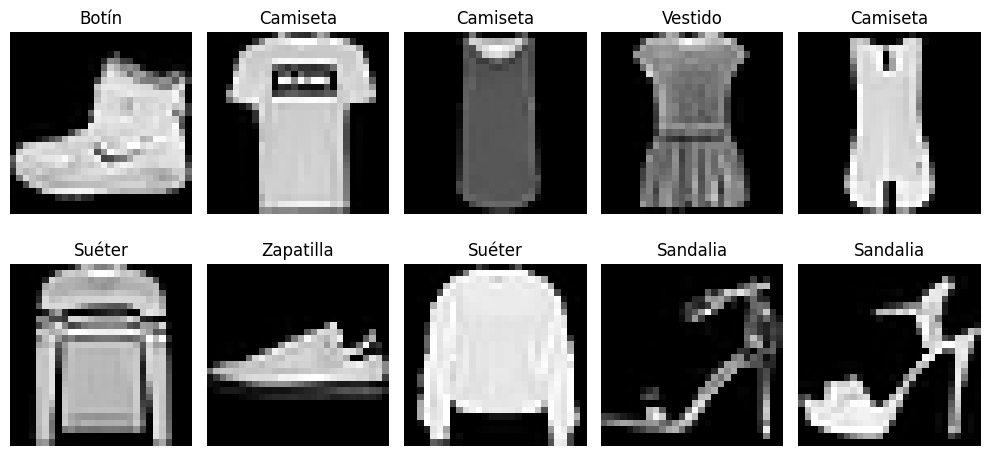

In [ ]:
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Preprocesamiento de los datos

Antes de entrenar la red neuronal, fue necesario preparar los datos.  
Primero, se normalizaron los valores de los píxeles al rango [0,1]. Luego, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

In [ ]:
# Normalización de los píxeles
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanar las imágenes: de 28x28 a 784
X_train = X_train.reshape(60000, 28 * 28)
X_test = X_test.reshape(10000, 28 * 28)

print("Nueva forma de X_train:", X_train.shape)
print("Nueva forma de X_test:", X_test.shape)
print("Valor mínimo en X_train:", X_train.min())
print("Valor máximo en X_train:", X_train.max())

Nueva forma de X_train: (60000, 784)
Nueva forma de X_test: (10000, 784)
Valor mínimo en X_train: 0.0
Valor máximo en X_train: 1.0


Se normalizaron los valores de los píxeles al rango entre 0 y 1, lo que favorece la estabilidad del entrenamiento y evita que valores demasiado altos afecten el aprendizaje del modelo. Posteriormente, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

## Construcción y definición del modelo MLP

Una vez finalizado el preprocesamiento, los datos quedaron listos para ser utilizados como entrada en una red neuronal multicapa (MLP).  

Cada imagen fue representada como un vector de 784 características, lo que permite usarla posteriormente en la etapa de definición y entrenamiento del modelo.

### Importación de librerías para la construcción del modelo

En esta etapa se importan las librerías de TensorFlow y Keras, las cuales permiten definir, compilar y entrenar la red neuronal multicapa utilizada en este trabajo.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Justificación inicial de la arquitectura

Se eligió una arquitectura MLP simple como punto de partida, ya que permite aplicar de manera directa los fundamentos revisados en la asignatura, como perceptrón multicapa, redes feed forward, funciones de activación y clasificación multiclase.

La función ReLU se utilizó en las capas ocultas debido a su buen desempeño durante el entrenamiento, mientras que Softmax se utilizó en la capa de salida porque permite obtener probabilidades para cada una de las 10 clases del dataset.

## Compilación del modelo

Una vez definida la arquitectura, se procedió a compilar el modelo. En esta etapa se seleccionó el optimizador, la función de pérdida y la métrica principal de evaluación que se utilizarán durante el entrenamiento.

Se utilizó el optimizador Adam por su buen desempeño en problemas de clasificación, la función de pérdida `sparse_categorical_crossentropy` debido a que las etiquetas están representadas como números enteros, y accuracy como métrica inicial para monitorear el aprendizaje del modelo.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Esta configuración permite que el modelo aprenda minimizando el error de clasificación y monitoreando su porcentaje de aciertos durante el entrenamiento.

## Entrenamiento del modelo

Una vez compilado el modelo, se realizó el proceso de entrenamiento utilizando el conjunto de datos de entrenamiento.

En esta etapa, la red neuronal ajusta sus pesos internos a partir de los ejemplos entregados, con el objetivo de minimizar la función de pérdida y mejorar su capacidad de clasificación.

Para esta primera configuración se utilizaron 10 épocas, un batch size de 32 y un 20% de los datos de entrenamiento como conjunto de validación, con el fin de monitorear el desempeño del modelo durante el aprendizaje.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8178 - loss: 0.5144 - val_accuracy: 0.8442 - val_loss: 0.4481
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8629 - loss: 0.3744 - val_accuracy: 0.8586 - val_loss: 0.3919
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8748 - loss: 0.3389 - val_accuracy: 0.8712 - val_loss: 0.3484
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8837 - loss: 0.3147 - val_accuracy: 0.8688 - val_loss: 0.3553
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8890 - loss: 0.2973 - val_accuracy: 0.8722 - val_loss: 0.3601
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8926 - loss: 0.2854 - val_accuracy: 0.8853 - val_loss: 0.3286
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8992 - loss: 0.2706 - val_accuracy: 0.8794 - val_loss: 0.3411
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9013 - loss: 0.2612 - 

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Análisis del entrenamiento

Durante el entrenamiento, el modelo mostró una mejora progresiva en el conjunto de entrenamiento, aumentando su accuracy desde 0.8178 hasta un valor cercano a 0.91 y reduciendo la pérdida desde 0.5144, lo que indica que logró aprender patrones relevantes del dataset.

En el conjunto de validación, la accuracy alcanzó valores cercanos a 0.89, con su mejor resultado de 0.8859 en la época 8. Esto sugiere que el modelo fue capaz de generalizar adecuadamente a datos no vistos.

Sin embargo, en las últimas épocas, las mejoras en validación fueron menores y presentaron ligeras fluctuaciones. Esto puede deberse a que el modelo ya aprendió gran parte de los patrones presentes en los datos, por lo que nuevas iteraciones no generaron mejoras significativas. Además, la cercanía entre los resultados de entrenamiento y validación indica que no se observa un sobreajuste importante.

## Visualización del entrenamiento

Para analizar el comportamiento del modelo durante el proceso de aprendizaje, se graficaron la accuracy y la función de pérdida tanto en entrenamiento como en validación.

Esto permite observar si el modelo mejora con las épocas y detectar posibles señales de sobreajuste o estancamiento.

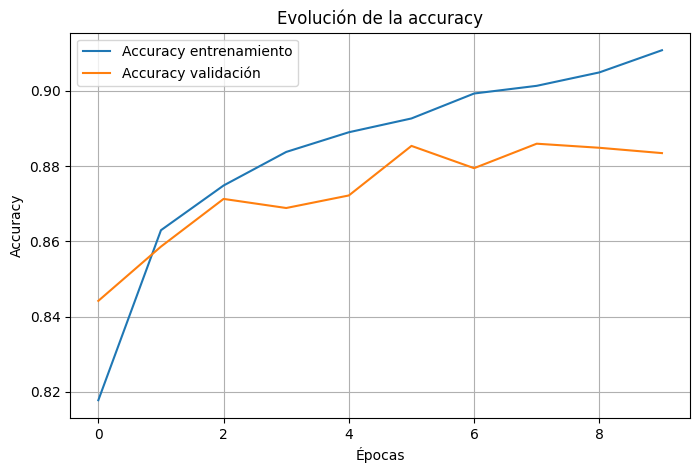

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución de la accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que el modelo aprende progresivamente, ya que la accuracy de entrenamiento aumenta de forma constante. La accuracy de validación también mejora, pero se estabiliza en las últimas épocas, lo que sugiere que el modelo alcanza un punto donde deja de generalizar mejor.

La pequeña diferencia entre ambas curvas indica un leve overfitting, aunque no es significativo, por lo que el modelo presenta un buen desempeño general.

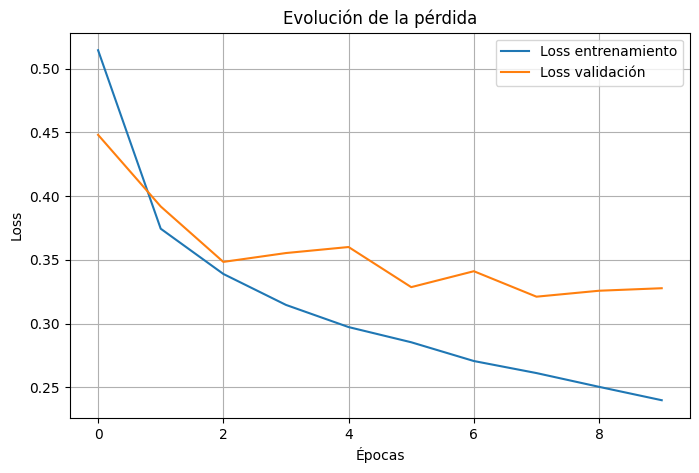

In [ ]:
# Gráfico de loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que la pérdida de entrenamiento disminuye constantemente, lo que indica un buen aprendizaje del modelo. La pérdida de validación también baja al inicio, pero luego se estabiliza y presenta pequeñas variaciones.

La diferencia entre ambas curvas sugiere un leve overfitting, aunque no es significativo, por lo que el modelo mantiene un buen equilibrio entre ajuste y generalización.

### Interpretación de los gráficos de entrenamiento

Los gráficos muestran que el modelo tuvo un aprendizaje progresivo durante el entrenamiento. La accuracy aumentó de forma sostenida en el conjunto de entrenamiento, mientras que en validación alcanzó valores cercanos a 0.89, lo que indica un buen desempeño general y una capacidad adecuada de generalización.

En cuanto a la pérdida, se observó una disminución continua en entrenamiento y una reducción inicial en validación, seguida de ligeras fluctuaciones en las últimas épocas. Esto sugiere que el modelo logró aprender patrones relevantes del dataset y que, hacia el final del entrenamiento, su desempeño comenzó a estabilizarse.

Además, la diferencia entre entrenamiento y validación se mantiene en un rango razonable, por lo que no se observa un sobreajuste importante, aunque sí una leve separación entre ambos comportamientos.

## Evaluación del modelo en el conjunto de prueba

Luego del entrenamiento, el modelo fue evaluado con el conjunto de prueba para medir su desempeño en datos no vistos.

### Evaluación general en test

Primero se evaluó el modelo sobre el conjunto de prueba para obtener una medida general de pérdida y accuracy.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Loss en test:", test_loss)
print("Accuracy en test:", test_accuracy)

Loss en test: 0.3528403043746948
Accuracy en test: 0.8776999711990356


El modelo obtuvo un accuracy cercano a 0.88 en el conjunto de test, lo que indica un buen nivel de generalización. Además, la pérdida se mantiene en valores adecuados, confirmando un desempeño estable en datos no vistos.

### Generación de predicciones

Se generaron las predicciones del modelo y se seleccionó la clase con mayor probabilidad para cada imagen.

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Los resultados muestran un desempeño general adecuado y métricas consistentes en el conjunto de prueba.

### Importación de herramientas para evaluación


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

### Cálculo de métricas

Con las predicciones obtenidas, se calcularon accuracy, precision, recall y F1-score.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8777
Precision: 0.881216662903811
Recall: 0.8777
F1-score: 0.8782382348441566


Estas métricas son importantes porque permiten evaluar el modelo de forma más completa. La accuracy muestra el desempeño general, mientras que precision, recall y F1-score ayudan a analizar con mayor detalle la calidad de la clasificación.

### Cuadro resumen de métricas

A continuación, se presenta un cuadro resumen con los valores obtenidos para cada métrica.

In [ ]:
metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})

metricas

,Métrica,Valor
0,Accuracy,0.877700
1,Precision,0.881217
2,Recall,0.877700
3,F1-score,0.878238


Se observa que las métricas presentan valores muy similares entre sí, lo que indica un desempeño equilibrado del modelo en el conjunto de prueba. Además, la precision es levemente superior, lo que sugiere una buena capacidad para clasificar correctamente las clases predichas.

### Reporte de clasificación por clase

Además de las métricas globales, se generó un reporte de clasificación para analizar el desempeño del modelo en cada clase del dataset.

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Camiseta       0.86      0.78      0.82      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.78      0.80      0.79      1000
     Vestido       0.86      0.92      0.89      1000
      Abrigo       0.84      0.71      0.77      1000
    Sandalia       0.97      0.96      0.96      1000
      Camisa       0.65      0.75      0.69      1000
   Zapatilla       0.96      0.94      0.95      1000
       Bolso       0.97      0.98      0.97      1000
       Botín       0.94      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Resultados de evaluación del modelo

El modelo fue evaluado con el conjunto de prueba, obteniendo un accuracy de 0.8777, una precision de 0.8812, un recall de 0.8777 y un F1-score de 0.8782. En general, estos resultados muestran un buen desempeño del modelo en la clasificación de imágenes no vistas.

Por clase, las mejores métricas se observaron en Pantalón, Sandalia, Zapatilla, Bolso y Botín, lo que sugiere que el modelo reconoce mejor prendas visualmente más diferenciables.

En cambio, clases como Camisa, Abrigo y Suéter presentaron un desempeño inferior, probablemente debido a la similitud visual entre estas categorías. Esto muestra que, aunque el modelo generaliza adecuadamente, algunas clases siguen siendo más difíciles de separar para una red MLP simple.

## Segunda configuración del modelo: MLP con Dropout

Agregar bloque entrecomillado



Con el objetivo de comparar configuraciones y analizar el efecto de la regularización, se implementó una segunda arquitectura MLP incorporando capas Dropout.

Esta técnica ayuda a reducir el sobreajuste, ya que durante el entrenamiento desactiva aleatoriamente una parte de las neuronas y favorece el aprendizaje de representaciones más robustas.

### Definición de la arquitectura con Dropout

In [ ]:
model_dropout = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

### Resumen del modelo con Dropout

In [ ]:
model_dropout.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Se incorporaron capas de Dropout para reducir el sobreajuste, desactivando neuronas de forma aleatoria durante el entrenamiento. Esto busca mejorar la generalización del modelo sin aumentar la cantidad de parámetros.

### Compilación del modelo con Dropout

In [ ]:
model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Se utilizó la misma configuración de optimizador, función de pérdida y métrica que en el modelo base, con el fin de mantener una comparación controlada.

### Entrenamiento del modelo con Dropout

A continuación, se entrenó la segunda configuración del modelo utilizando los mismos parámetros base, con el fin de comparar su desempeño frente a la arquitectura original.

In [ ]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7602 - loss: 0.6726 - val_accuracy: 0.8401 - val_loss: 0.4332
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8284 - loss: 0.4767 - val_accuracy: 0.8615 - val_loss: 0.3814
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8452 - loss: 0.4333 - val_accuracy: 0.8596 - val_loss: 0.3842
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8533 - loss: 0.4087 - val_accuracy: 0.8716 - val_loss: 0.3533
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8575 - loss: 0.3963 - val_accuracy: 0.8717 - val_loss: 0.3531
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8621 - loss: 0.3826 - val_accuracy: 0.8712 - val_loss: 0.3564
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8647 - loss: 0.3693 - val_accuracy: 0.8758 - val_loss: 0.3493
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8655 - loss: 0.3640 - 

## Análisis del modelo con Dropout

Se probó una segunda configuración incorporando capas Dropout para reducir el sobreajuste y comparar su efecto frente al modelo base.

Aunque el modelo mostró un aprendizaje estable, su desempeño final fue inferior al del modelo base. Esto sugiere que, en este caso, la regularización aplicada no aportó una mejora en los resultados.

### Evaluación general del modelo con Dropout

Se evaluó el modelo con Dropout en el conjunto de prueba para obtener la pérdida y la accuracy general.

In [ ]:
test_loss_dropout, test_accuracy_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)

print("Loss en test (Dropout):", test_loss_dropout)
print("Accuracy en test (Dropout):", test_accuracy_dropout)

Loss en test (Dropout): 0.3493232727050781
Accuracy en test (Dropout): 0.8736000061035156


El modelo con Dropout obtuvo un buen desempeño, con una accuracy cercana a 0.87. Sin embargo, su rendimiento fue levemente inferior al modelo base. Esto sugiere que, aunque el Dropout ayuda a evitar el sobreajuste, en este caso no aportó una mejora y pudo haber reducido ligeramente la capacidad de aprendizaje del modelo.

### Generación de predicciones con Dropout

Se generaron las predicciones del modelo sobre el conjunto de prueba.

In [ ]:
y_prob_dropout = model_dropout.predict(X_test)
y_pred_dropout = np.argmax(y_prob_dropout, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Se obtuvieron las predicciones del modelo en el conjunto de prueba, convirtiendo las probabilidades en clases finales mediante el uso de argmax.

### Cálculo de métricas del modelo con Dropout

Con las predicciones obtenidas, se calcularon accuracy, precision, recall y F1-score.

In [ ]:
accuracy_dropout = accuracy_score(y_test, y_pred_dropout)
precision_dropout = precision_score(y_test, y_pred_dropout, average='weighted')
recall_dropout = recall_score(y_test, y_pred_dropout, average='weighted')
f1_dropout = f1_score(y_test, y_pred_dropout, average='weighted')

print("Accuracy Dropout:", accuracy_dropout)
print("Precision Dropout:", precision_dropout)
print("Recall Dropout:", recall_dropout)
print("F1-score Dropout:", f1_dropout)

Accuracy Dropout: 0.8736
Precision Dropout: 0.8731864845653933
Recall Dropout: 0.8736
F1-score Dropout: 0.8724183803775925


El modelo con Dropout obtuvo un desempeño equilibrado, con métricas cercanas a 0.87. Sin embargo, su rendimiento fue ligeramente inferior al modelo base, lo que sugiere que la regularización no aportó una mejora significativa en este caso.